# Phase 3: Biologically Inspired Hidden Perturbations (4-Hidden-Layer Networks)

Each model is a **4-hidden-layer** SLAYER SNN. A perturbation is injected at the
spike output of **one selectable hidden layer** (the *injection site*), and the
site is swept across layers 1–4 to trace how temporal sensitivity changes with
depth. For every (site, perturbation level) a fresh model is trained end-to-end
with the perturbation active at that site, then evaluated at the same level.

**One subplot per injection site (hidden layer).** Within each subplot:
- **SGD-delay** (solid, filled circles): SNN with learnable axonal delays.
- **SGD** (dashed, × markers): baseline SNN without delays.
- Three dataset variants: **Whole** (blue), **Part** (green), **Norm** (red).

Results are read directly from each perturbation's `log/` folder, so the figures
update as more runs finish. Two kinds of incompleteness are handled for now:
- Sweeps that only reached a prefix of their levels are **forward-filled** —
  levels beyond the last finished one repeat that last value (shaded grey and
  marked *forward-filled*).
- Perturbation types whose `log/` folder is still empty show a **placeholder**.

## 3A: Per-Spike Jitter

Independent Gaussian noise (σ ms) added to each spike time at the injection
site. Full sweep: σ = 0, 5, 10, 15, 20, 25 ms (currently only σ = 0 and 5 are
computed; larger σ are forward-filled).

In [1]:
import json
import pathlib
import re

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib.axes import Axes

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

# Dataset variants: file token -> display label, and display label -> colour.
DATASETS = ["whole", "part", "norm"]
DATASET_LABELS = {"whole": "Whole", "part": "Part", "norm": "Norm"}
COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}

# Line style per model variant (delay vs no-delay).
DELAY_STYLES = {
    True:  {"marker": "o", "linestyle": "-",  "markersize": 5, "fill": 0.12},
    False: {"marker": "x", "linestyle": "--", "markersize": 6, "fill": 0.08},
}

# Canonical full sweeps, taken from the *_train.py scripts. A run may only have
# completed a prefix of these levels; the rest are forward-filled for now.
JITTER_SIGMAS = [0, 5, 10, 15, 20, 25]
SHIFT_SIGMAS = [0, 5, 10, 15, 20, 25]
DELETION_PDS = [0.0, 0.2, 0.4, 0.6, 0.8]


def discover_sites(log_dir: pathlib.Path, ptype: str) -> list[int]:
    """Return the injection-site (hidden-layer) indices present in a log folder.

    Sweep files are named
    ``{ptype}_perturb{layer}_{dataset}_{delay}_{ptype}_sweep_results.json``;
    the integer after ``perturb`` is the hidden layer the perturbation was
    injected at.

    Args:
        log_dir: Folder holding the sweep-result JSON files.
        ptype: Perturbation type token, e.g. ``"jitter"``.

    Returns:
        Sorted list of distinct site indices, empty if the folder has none.
    """
    pattern = re.compile(
        rf"^{ptype}_perturb(\d+)_\w+_(?:delay|nodelay)_{ptype}_sweep_results\.json$"
    )
    sites = set()
    for path in log_dir.glob(f"{ptype}_perturb*_{ptype}_sweep_results.json"):
        match = pattern.match(path.name)
        if match:
            sites.add(int(match.group(1)))
    return sorted(sites)


def load_sweep_padded(
    path: pathlib.Path,
    full_levels: list[float],
) -> tuple[np.ndarray, np.ndarray, np.ndarray, int] | None:
    """Load a sweep JSON and reindex it onto the full level grid.

    Levels beyond the last completed one are forward-filled with that last
    value so partial sweeps still span the full x-range. Accuracies are
    converted to percentages.

    Args:
        path: Path to a ``*_sweep_results.json`` file.
        full_levels: Canonical, ascending perturbation levels for this sweep.

    Returns:
        Tuple ``(levels, means_pct, stds_pct, n_real)`` where ``n_real`` is the
        number of leading levels backed by real data, or ``None`` if the file
        does not exist.
    """
    if not path.exists():
        return None
    with open(path) as fh:
        raw = json.load(fh)

    available = {float(key): value for key, value in raw.items()}
    levels: list[float] = []
    means: list[float] = []
    stds: list[float] = []
    last_mean: float | None = None
    last_std: float | None = None
    n_real = 0

    for level in full_levels:
        if float(level) in available:
            entry = available[float(level)]
            last_mean = entry["mean"] * 100.0
            last_std = entry["std"] * 100.0
            n_real = len(levels) + 1
        if last_mean is None:
            continue  # No completed level at or below this one yet.
        levels.append(float(level))
        means.append(last_mean)
        stds.append(last_std)

    if not levels:
        return None
    return np.array(levels), np.array(means), np.array(stds), n_real


def _plot_site(
    ax: Axes,
    log_dir: pathlib.Path,
    ptype: str,
    site: int,
    full_levels: list[float],
    xlabel: str,
    xlim: tuple[float, float],
) -> None:
    """Draw the dataset x delay curves for a single injection site.

    The y-limit is intentionally left to autoscale here: axes share the y-axis,
    so pinning it per-subplot would freeze the range before later, taller
    subplots are drawn. ``plot_perturbation`` fixes the shared bottom to 0 once
    every subplot is populated.
    """
    real_boundary: float | None = None

    for use_delay in (True, False):
        delay_tag = "delay" if use_delay else "nodelay"
        style = DELAY_STYLES[use_delay]
        for dataset in DATASETS:
            fname = (
                f"{ptype}_perturb{site}_{dataset}_{delay_tag}"
                f"_{ptype}_sweep_results.json"
            )
            loaded = load_sweep_padded(log_dir / fname, full_levels)
            if loaded is None:
                continue  # This dataset/variant has not been run at this site.
            levels, means, stds, n_real = loaded
            color = COLORS[DATASET_LABELS[dataset]]
            ax.plot(
                levels, means, marker=style["marker"],
                linestyle=style["linestyle"], color=color,
                markersize=style["markersize"], linewidth=1.8,
            )
            ax.fill_between(
                levels, means - stds, means + stds,
                color=color, alpha=style["fill"],
            )
            boundary = levels[n_real - 1]
            real_boundary = (
                boundary if real_boundary is None
                else max(real_boundary, boundary)
            )

    # Shade the forward-filled tail so placeholder levels are visually distinct.
    if real_boundary is not None and real_boundary < xlim[1]:
        ax.axvspan(real_boundary, xlim[1], color="grey", alpha=0.07, zorder=0)
        ax.text(
            0.97, 0.03, "forward-filled", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=7, color="grey", style="italic",
        )

    ax.set_title(f"Layer {site}")
    ax.set_xlabel(xlabel)
    ax.set_xlim(*xlim)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)


def _add_legend(ax: Axes) -> None:
    """Attach the shared variant/dataset legend to one axis."""
    handles = [
        mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                      markersize=5, linewidth=1.8, label="SGD-delay"),
        mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                      markersize=6, linewidth=1.8, label="SGD"),
        mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole"),
        mlines.Line2D([], [], color=COLORS["Part"], linewidth=2.5, label="Part"),
        mlines.Line2D([], [], color=COLORS["Norm"], linewidth=2.5, label="Norm"),
    ]
    ax.legend(handles=handles, loc="upper right", framealpha=0.9, ncol=2)


def plot_perturbation(
    ptype: str,
    log_dir: str,
    full_levels: list[float],
    xlabel: str,
    xlim: tuple[float, float],
    suptitle: str,
) -> None:
    """Plot one perturbation type as a row of per-site subplots.

    Discovers the injection sites present under ``log_dir`` and draws one
    subplot per site. When no results exist yet (empty folder) a single
    placeholder panel is shown instead.

    Args:
        ptype: Perturbation type token (``"jitter"``/``"shift"``/``"deletion"``).
        log_dir: Path to the perturbation's ``log`` folder.
        full_levels: Canonical sweep levels for the x-axis.
        xlabel: X-axis label.
        xlim: X-axis limits.
        suptitle: Figure title.
    """
    log_path = pathlib.Path(log_dir)
    sites = discover_sites(log_path, ptype)

    if not sites:
        fig, ax = plt.subplots(figsize=(6, 4.5))
        ax.text(
            0.5, 0.5, f"No {ptype} results yet\n(placeholder)",
            ha="center", va="center", fontsize=14, color="grey",
            transform=ax.transAxes,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(suptitle)
        fig.tight_layout()
        plt.show()
        return

    fig, axes = plt.subplots(
        1, len(sites), figsize=(5.2 * len(sites), 4.5),
        squeeze=False, sharey=True,
    )
    for ax, site in zip(axes[0], sites):
        _plot_site(ax, log_path, ptype, site, full_levels, xlabel, xlim)
    # Shared y-axis: pin the bottom to 0 once all sites are drawn so autoscale
    # has already grown the top to cover the tallest subplot.
    axes[0][0].set_ylim(bottom=0)
    axes[0][0].set_ylabel("Test Accuracy (%)")
    _add_legend(axes[0][-1])
    fig.suptitle(suptitle, fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()

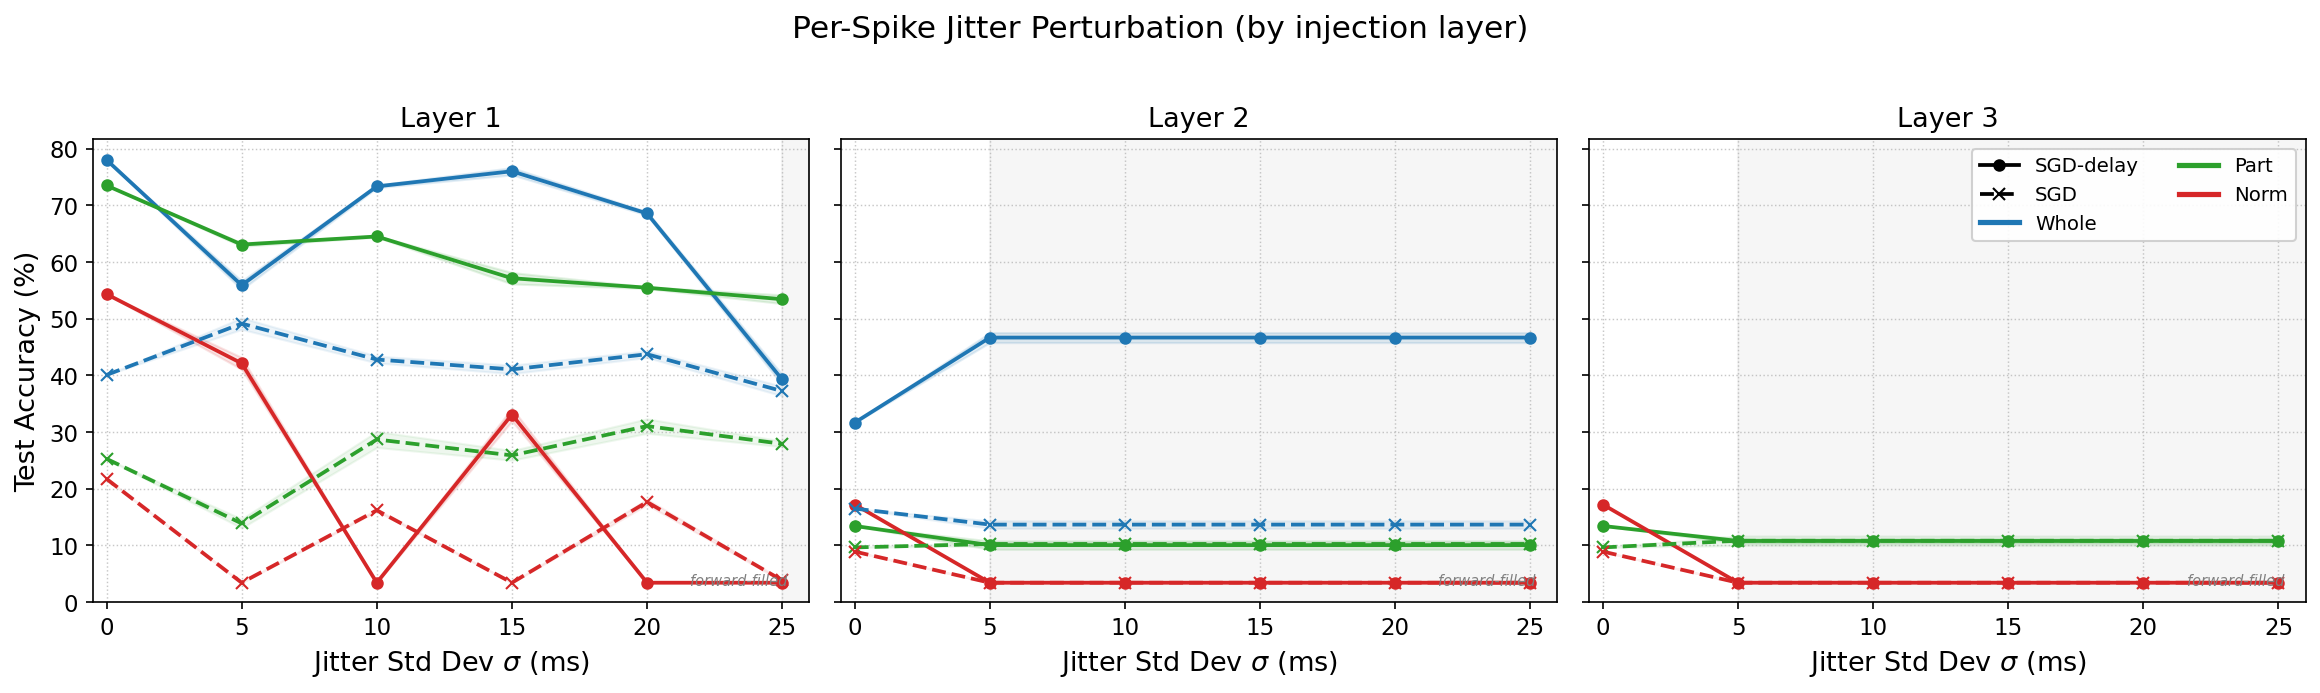

In [2]:
plot_perturbation(
    ptype="jitter",
    log_dir="jitter/log",
    full_levels=JITTER_SIGMAS,
    xlabel=r"Jitter Std Dev $\sigma$ (ms)",
    xlim=(-0.5, 26),
    suptitle="Per-Spike Jitter Perturbation (by injection layer)",
)

## 3B: Per-Neuron Shift

The same Gaussian offset is applied to **all spikes from a given hidden neuron**,
preserving intra-neuron ISI while disrupting cross-neuron timing. Full sweep:
σ = 0, 5, 10, 15, 20, 25 ms. *(No shift results yet — placeholder below.)*

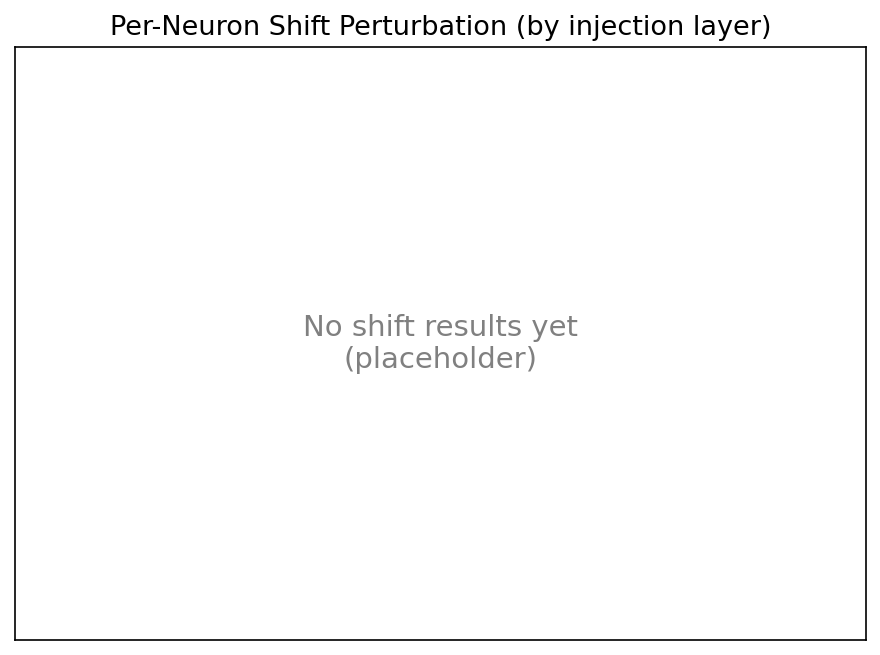

In [3]:
plot_perturbation(
    ptype="shift",
    log_dir="shift/log",
    full_levels=SHIFT_SIGMAS,
    xlabel=r"Shift Std Dev $\sigma$ (ms)",
    xlim=(-0.5, 26),
    suptitle="Per-Neuron Shift Perturbation (by injection layer)",
)

## 3C: Hidden Spike Deletion

Each spike at the injection site is independently dropped with probability
$p_d$, reducing the total spike count while preserving the timing of surviving
spikes. Full sweep: $p_d$ = 0, 0.2, 0.4, 0.6, 0.8. *(No deletion results yet —
placeholder below.)*

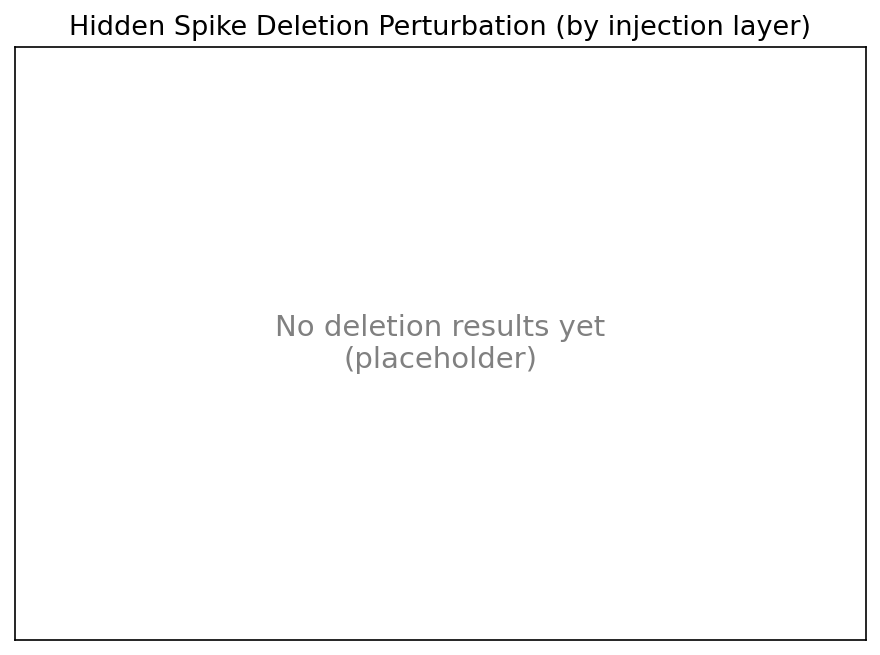

In [4]:
plot_perturbation(
    ptype="deletion",
    log_dir="deletion/log",
    full_levels=DELETION_PDS,
    xlabel=r"Deletion Probability $p_d$",
    xlim=(-0.02, 0.82),
    suptitle="Hidden Spike Deletion Perturbation (by injection layer)",
)